Loaded delta-0.1-45.out: angle=45.0°, Fx=1.777e+01, Fy=1.777e+01, components=x,y, n_points=41
maximum displacement (x): 0.07988
sigma_noise added (x): 7.988e-05 (0.1% of maximum displacement)
realized experimental noise (x): 8.681e-05
maximum displacement (y): 0.01679
sigma_noise added (y): 1.679e-05 (0.1% of maximum displacement)
realized experimental noise (y): 1.579e-05
sigma_noise prior: Exp(beta=125.3)
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\data_vs_noise_x.pdf


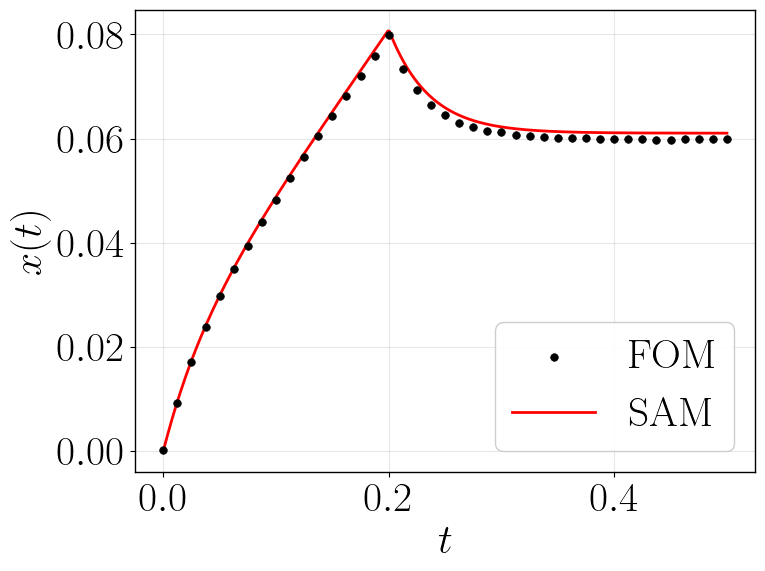

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\data_vs_noise_y.pdf


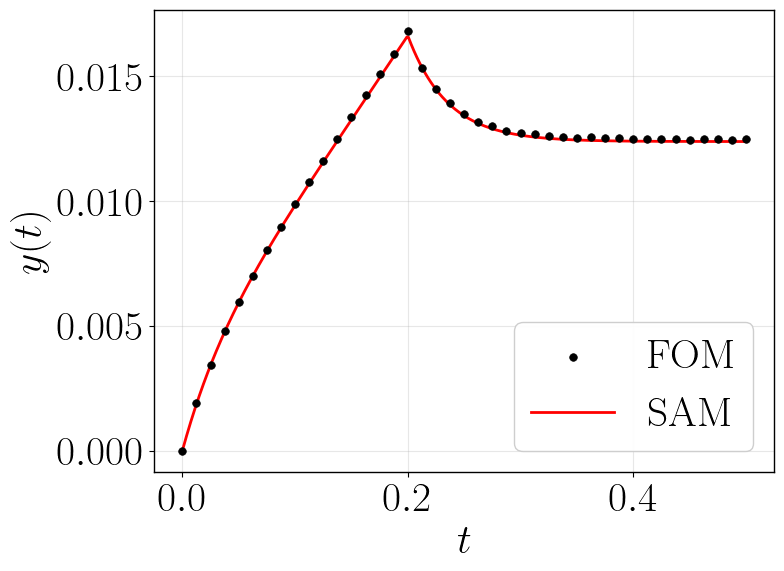

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\model_error_x.pdf


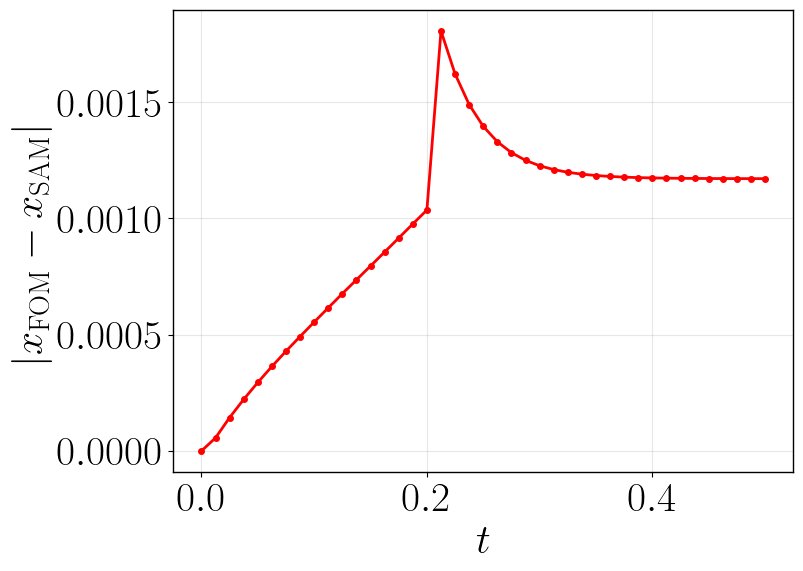

x model error: max |error| = 0.00180676, mean |error| = 0.000961858, relative L2 error = 0.0182519
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\model_error_y.pdf


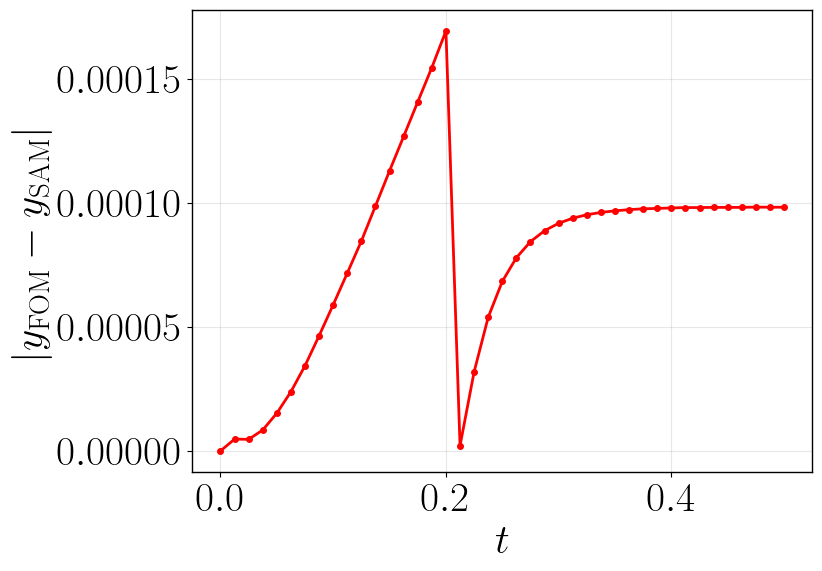

y model error: max |error| = 0.000169249, mean |error| = 7.83408e-05, relative L2 error = 0.00736106
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\prior.pdf


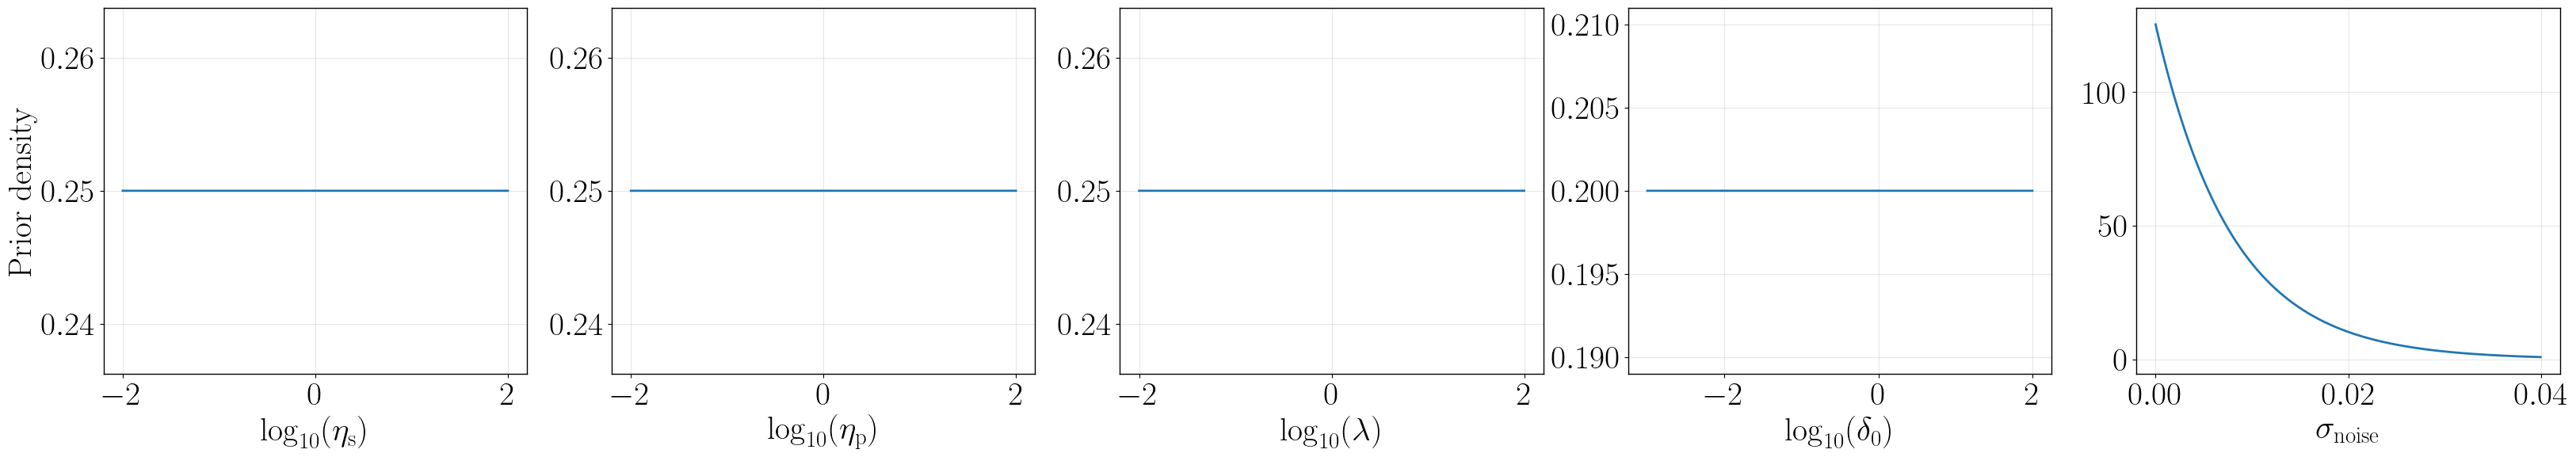


Preparing MCMC: ndim=5, walkers=10, steps=5000, warmup=True

Initial walkers (physical):
  00: [1.24687867e+01 3.04223037e-01 1.07733547e+01 5.29432722e+00
 1.06463959e-02]
  01: [5.69526267e-01 5.09401190e+01 2.61880929e-01 6.87936990e+01
 1.11026931e-02]
  02: [2.71889026e+01 3.76236114e+00 7.63470213e+01 4.25722683e-02
 8.65378653e-03]
  03: [6.15845988e+00 1.95454851e+01 3.73666776e+01 7.11702564e-02
 5.82955157e-04]
  04: [2.38072587e-02 5.93822700e-01 1.29877520e+01 2.22730174e-01
 9.05279275e-03]
  05: [7.98894455e+01 8.10876823e-02 6.00557827e-02 8.85843077e-03
 1.08111211e-02]
  06: [1.10804860e+01 1.65325235e+00 7.36010508e-01 4.46280105e-03
 8.95677938e-03]
  07: [1.39398218e+01 1.79998557e-02 1.49697678e-02 2.39069752e-01
 2.23551653e-03]
  08: [3.25427710e-02 2.04420614e+01 4.14150289e-02 1.36315972e-02
 2.56190114e-03]
  09: [6.33204149e-01 3.36246364e+00 5.39753930e+00 2.23393212e+00
 1.32300134e-03]

Warm-up: 500 steps x 10 walkers


100%|██████████| 500/500 [01:04<00:00,  7.80it/s]



Walkers after warm-up (physical):
  00: [0.60400432 0.96838124 0.1021754  0.09686905 0.00212695]
  01: [0.6434449  0.89582263 0.11129481 0.09865072 0.00268379]
  02: [6.42276185e-01 8.83460395e-01 1.03974095e-01 1.08187388e-01
 2.71729780e-04]
  03: [6.05701438e-01 8.40705356e-01 1.15136103e-01 1.08122461e-01
 3.77230325e-04]
  04: [0.66715076 0.83151406 0.09498558 0.12648554 0.00213869]
  05: [0.61498546 0.98691332 0.1099545  0.11709341 0.00209891]
  06: [6.26536596e-01 9.30607087e-01 9.84054681e-02 1.76711311e-01
 8.92555360e-04]
  07: [0.52668009 0.76431327 0.10829732 0.12653901 0.00136577]
  08: [0.57610965 0.84222999 0.11666083 0.0968021  0.00102182]
  09: [6.43878264e-01 9.30218935e-01 1.12852684e-01 1.34554845e-01
 9.06425646e-05]


  3%|▎         | 160/5000 [00:24<13:51,  5.82it/s]

In [ ]:
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from packages.main import InferenceProcedure

model = InferenceProcedure(
    force=8 * np.pi,
    material_model="viscoelastic",
    boundary_model="bounded",
    theta=45,
    t_unload=0.2,
    delta0 = 0.1,
    sigma_bias=None,
    sigma_noise_percent=2.0,
    nsteps=5000,
    use_y = True,
    thin_factor=5)

model.load_data("data/linear_viscoelastic/angle45/delta-0.1-45.out")
model.plot_data(theta_true=[0.5, 0.9, 0.1]) # [eta_s, eta_p, lambda]
model.plot_model_error(theta_true=[0.5, 0.9, 0.1])
model.plot_prior()
model.run_mcmc( warmup = True)
model.plot_results()